# Background Cosmology

This notebook explores the fundamental background cosmology equations, explaining the methods and physics for modeling the evolution of the Universe. It covers the Hubble parameter, comoving distances, and basic dark energy models.

**Contents**
1. Hubble Parameter Evolution $E(z)$
2. $w$CDM Dark Energy Model ($w$ constant)
3. CPL Parameterization ($w(a)$ evolving)


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import toolscosmo

plt.rcParams.update({'font.size': 13, 'lines.linewidth': 2.2})


## 1. Hubble Parameter Evolution $E(z)$

The normalized Hubble parameter $E(z) = H(z) / H_0$ describes the expansion history of the universe. In a flat universe, it is given by the Friedmann equation:

$$E(z)^2 = \Omega_{r,0}(1+z)^4 + \Omega_{m,0}(1+z)^3 + \Omega_{\mathrm{DE}}(z)$$

For a standard $\Lambda$CDM cosmology, the dark energy term is a constant cosmological constant, so $\Omega_{\mathrm{DE}}(z) = \Omega_{\Lambda,0}$. In models with dark energy, this term evolves dynamically. We can also include extensions like massive neutrinos.


In [2]:
## set parameters
par_lcdm = toolscosmo.par('lcdm')
par_wcdm = toolscosmo.par(DE='wcdm')
par_growing_nu = toolscosmo.par(DE='growing_neutrino_mass')
par_lcdm.cosmo.solver = 'toolscosmo'
par_wcdm.cosmo.solver = 'toolscosmo'
par_growing_nu.cosmo.solver = 'toolscosmo'

zs = 10**np.linspace(-2, np.log10(7), 100)

Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done


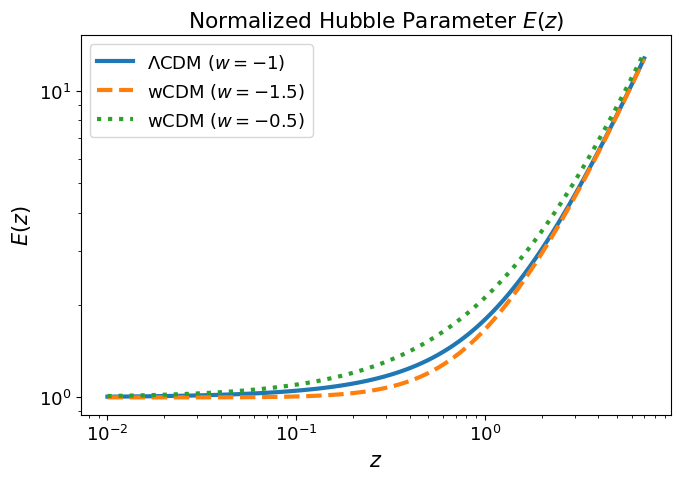

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.loglog(zs, toolscosmo.Ez_model(par_lcdm)(zs), lw=3, ls='-', label='$\Lambda$CDM ($w=-1$)')

par_wcdm.DE.w = -1.5
ax.loglog(zs, toolscosmo.Ez_model(par_wcdm)(zs), lw=3, ls='--', label='wCDM ($w=-1.5$)')
par_wcdm.DE.w = -0.5
ax.loglog(zs, toolscosmo.Ez_model(par_wcdm)(zs), lw=3, ls=':', label='wCDM ($w=-0.5$)')

ax.set_title('Normalized Hubble Parameter $E(z)$')
ax.set_xlabel('$z$', fontsize=15)
ax.set_ylabel('$E(z)$', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()


We can also check distance measures, such as the **comoving distance** $D_C(z)$:

$D_C(z) = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$


Preparing cosmological solvers...
...done


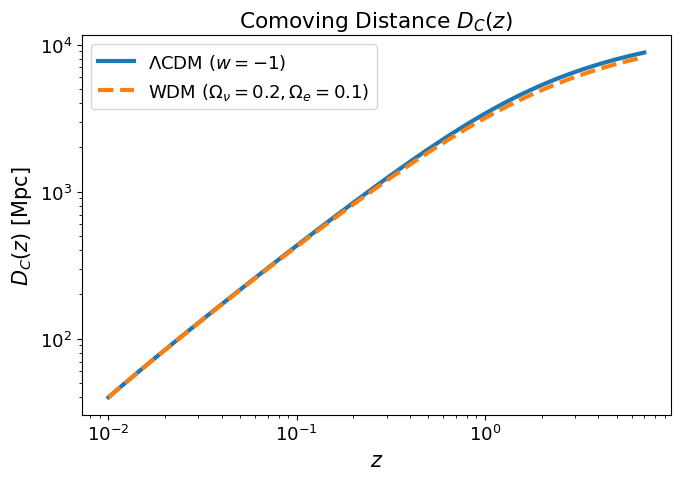

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

par_wcdm.DE.w = -1.0
ax.loglog(zs, toolscosmo.comoving_distance(zs, par_wcdm), lw=3, ls='-', label='$\Lambda$CDM ($w=-1$)')

par_growing_nu.DE.Onu  = 0.2
par_growing_nu.DE.Oede = 0.1
ax.loglog(zs, toolscosmo.comoving_distance(zs, par_growing_nu), lw=3, ls='--', 
          label=r'WDM ($\Omega_\nu=0.2, \Omega_e=0.1$)')

ax.set_title('Comoving Distance $D_C(z)$')
ax.set_xlabel('$z$', fontsize=15)
ax.set_ylabel('$D_C(z)$ [Mpc]', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()


## 2. wCDM Dark Energy Model

In the $w$CDM model, dark energy has a constant equation of state (EoS) parameter $w$. The dark energy density evolves as:

$$\Omega_{\mathrm{DE}}(z) = \Omega_{\mathrm{DE},0} (1+z)^{3(1+w)}$$

Here we visualize how changing the constant $w$ affects $E(z)$, the luminosity distance $D_L(z)$, and the distance modulus $\mu(z)$.


Preparing cosmological solvers...
...done


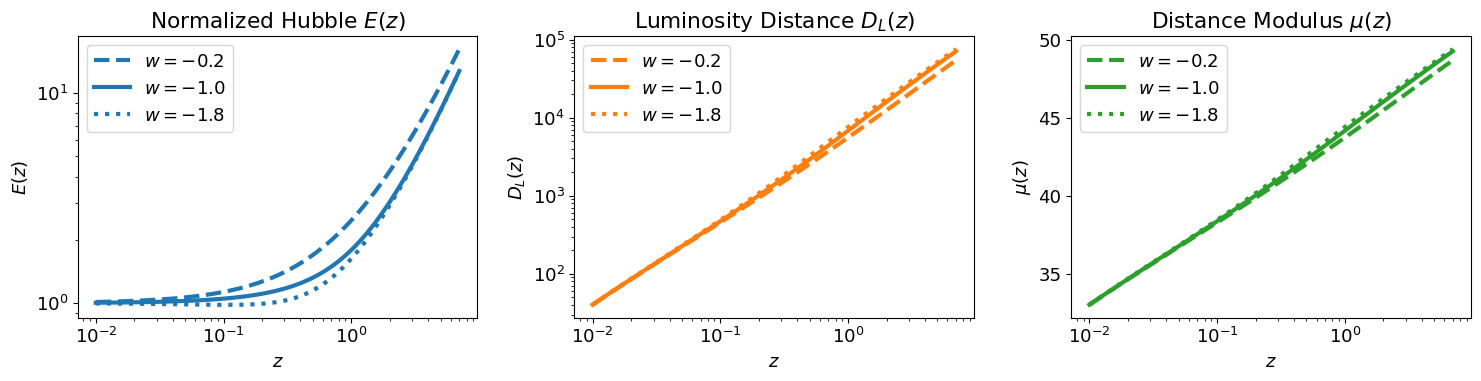

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
par = toolscosmo.par(DE='wcdm')

# 1. Hubble Parameter
ax = axs[0] 
par.DE.w = -0.2
ax.loglog(zs, toolscosmo.Ez_model(par)(zs), c='C0', ls='--', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.0
ax.loglog(zs, toolscosmo.Ez_model(par)(zs), c='C0', ls='-', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.8
ax.loglog(zs, toolscosmo.Ez_model(par)(zs), c='C0', ls=':', lw=3, label=f'$w={par.DE.w}$')
ax.set_title('Normalized Hubble $E(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$E(z)$')
ax.legend()

# 2. Luminosity Distance
ax = axs[1] 
par.DE.w = -0.2
ax.loglog(zs, toolscosmo.luminosity_distance(zs, par), c='C1', ls='--', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.0
ax.loglog(zs, toolscosmo.luminosity_distance(zs, par), c='C1', ls='-', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.8
ax.loglog(zs, toolscosmo.luminosity_distance(zs, par), c='C1', ls=':', lw=3, label=f'$w={par.DE.w}$')
ax.set_title('Luminosity Distance $D_L(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$D_L(z)$')
ax.legend()

# 3. Distance Modulus
ax = axs[2] 
par.DE.w = -0.2
ax.semilogx(zs, toolscosmo.distance_modulus(zs, par), c='C2', ls='--', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.0
ax.semilogx(zs, toolscosmo.distance_modulus(zs, par), c='C2', ls='-', lw=3, label=f'$w={par.DE.w}$')
par.DE.w = -1.8
ax.semilogx(zs, toolscosmo.distance_modulus(zs, par), c='C2', ls=':', lw=3, label=f'$w={par.DE.w}$')
ax.set_title('Distance Modulus $\mu(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$\mu(z)$')
ax.legend()

plt.tight_layout()
plt.show()


## 3. CPL Parameterization

The Chevallier-Polarski-Linder (CPL) parametrization provides a dynamic equation of state for dark energy:

$$w(a) = w_0 + w_a(1-a) = w_0 + w_a \frac{z}{1+z}$$

> **Note:** For a highly detailed exploration of the CPL model, please see the dedicated `example_CPL.ipynb` notebook. Here, we present a brief summary of its effect on distances and $E(z)$.


Preparing cosmological solvers...
...done


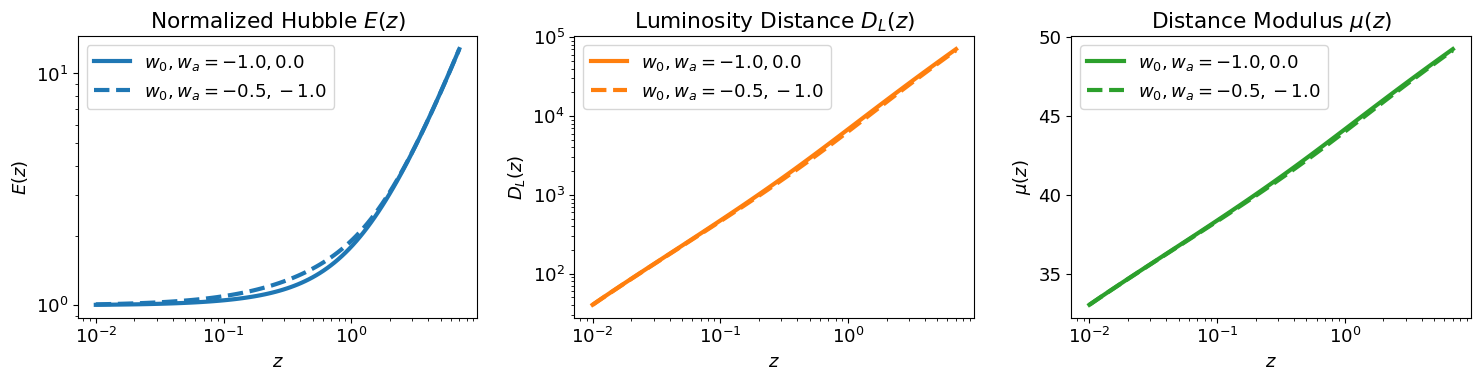

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
par = toolscosmo.par(DE='cpl')

# 1. Hubble Parameter
ax = axs[0] 
par.DE.w0, par.DE.wa = -1.0, 0.0
ax.loglog(zs, toolscosmo.Ez_model(par)(zs), c='C0', lw=3, ls='-', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
par.DE.w0, par.DE.wa = -0.5, -1.0
ax.loglog(zs, toolscosmo.Ez_model(par)(zs), c='C0', lw=3, ls='--', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
ax.set_title('Normalized Hubble $E(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$E(z)$')
ax.legend()

# 2. Luminosity Distance
ax = axs[1] 
par.DE.w0, par.DE.wa = -1.0, 0.0
ax.loglog(zs, toolscosmo.luminosity_distance(zs, par), c='C1', lw=3, ls='-', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
par.DE.w0, par.DE.wa = -0.5, -1.0
ax.loglog(zs, toolscosmo.luminosity_distance(zs, par), c='C1', lw=3, ls='--', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
ax.set_title('Luminosity Distance $D_L(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$D_L(z)$')
ax.legend()

# 3. Distance Modulus
ax = axs[2] 
par.DE.w0, par.DE.wa = -1.0, 0.0
ax.semilogx(zs, toolscosmo.distance_modulus(zs, par), c='C2', lw=3, ls='-', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
par.DE.w0, par.DE.wa = -0.5, -1.0
ax.semilogx(zs, toolscosmo.distance_modulus(zs, par), c='C2', lw=3, ls='--', label=f'$w_0,w_a={par.DE.w0},{par.DE.wa}$')
ax.set_title('Distance Modulus $\mu(z)$')
ax.set_xlabel('$z$')
ax.set_ylabel('$\mu(z)$')
ax.legend()

plt.tight_layout()
plt.show()
